# Data exploration: SKEMPI antibody-antigen dataset

**SKEMPI 2.0** is a curated database of protein-protein mutations paired with experimentally measured binding-affinity changes (ΔΔG). This project trains only on its antibody-antigen (`AB/AG`) subset: single- and multi-point mutations on an antibody or antigen chain, each with a measured or bounded ΔΔG describing how the mutation shifts binding affinity relative to wild type.

This notebook is a short tour, not a deep dive: what the processed dataset looks like, how homology deduplication shrank it, what splits stratify on (and what they don't), one real finding (ΔΔG vs. interface region), and the open gaps. Full detail lives in `docs/01_data_exploration.md` and `docs/future_work.md`.

In [1]:
import sys
from pathlib import Path


def resolve_repo_root() -> Path:
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


def add_repo_root_to_sys_path() -> Path:
    repo_root = resolve_repo_root()
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    return repo_root


REPO_ROOT = add_repo_root_to_sys_path()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from notebooks.utils import load_processed_dataframe
from shared.constants import InterfaceRegion

sns.set_theme(style="whitegrid")

REGION_ORDER = [region.value for region in InterfaceRegion]
REGION_PALETTE = dict(zip(REGION_ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

df = load_processed_dataframe()
samples = df.drop_duplicates("sample_id")

print(f"Total samples (distinct SKEMPI measurements): {len(samples)}")
print(f"Point-mutation rows (multi-point entries exploded): {len(df)}")
print("\nLabel type breakdown:")
print(samples["label_type"].value_counts())

Total samples (distinct SKEMPI measurements): 1057
Point-mutation rows (multi-point entries exploded): 2083

Label type breakdown:
label_type
bounded    919
n.b.        79
ineq        59
Name: count, dtype: int64


## Homology deduplication

Some SKEMPI rows re-measure the exact same mutation set on the exact same antibody-antigen pair, just re-crystallized under a different PDB code (`data/homology_dedup.py`'s `discard_homology_siblings`, run once before splitting) — a duplicate deposition, not new information. One representative per homology group is kept; every other member is dropped before splits are assigned.

Per `docs/future_work.md`'s pipeline run record, this discarded **154 of 1211** raw antibody-antigen SKEMPI rows (15 of 55 PDBs affected), leaving the **1057 samples** loaded above. That final count of 1057 is re-verified directly above from the real processed data on disk; the pre-dedup 1211/154 figures are cited from `docs/future_work.md` rather than recomputed here, since reproducing them requires re-running the full download+build pipeline (network access to the raw SKEMPI table and PDB structures).

## Stratification: what splits control for, and what they don't

Both split schemes group by `complex_name` (not raw `pdb_id`, which undercounted — SKEMPI often re-crystallizes the same complex under a different PDB code) so no complex leaks across train/val:

- **`held_out_pdb`**: every record of a given complex goes entirely to one side (zero complex overlap between train and val).
- **`same_pdb_allowed`**: a fraction of complexes are held out entirely (genuinely new complexes in val), the rest split per-sample so val also contains complexes seen in train but with a different mutation.

Two axes were **considered but not implemented**: stratifying by mutation location (antibody-side vs. antigen-side) and by alanine-scanning status. Alanine scanning is the dominant single-point-mutation category (~52% of single-point samples) and is measurably more destabilizing on average, so it's a real risk the model could shortcut on "alanine-ness" instead of learning real structure/sequence signal — see Gaps below.

## ΔΔG by interface region

Does mutation location within the interface (`support`/`core`/`rim`/`surface`/`interior`, from SKEMPI's own `iMutation_Location(s)` field) associate with how destabilizing a mutation tends to be? Restricted to rows with a numeric ΔΔG (positive = weakens binding, by SKEMPI convention).

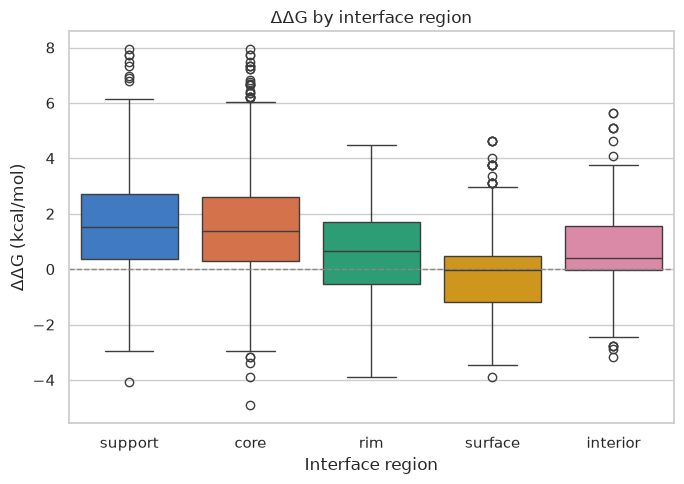

Kruskal-Wallis across regions: H=237.98, p=2.52e-50


In [3]:
def rows_with_numeric_ddg(data):
    return data[data["ddg_kcal_mol"].notna()].copy()


def categories_present(data, column, order):
    return [category for category in order if category in data[column].unique()]


plot_df = rows_with_numeric_ddg(df)
regions_present = categories_present(plot_df, "interface_region", REGION_ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=plot_df, x="interface_region", y="ddg_kcal_mol", order=regions_present,
    hue="interface_region", palette=REGION_PALETTE, legend=False, ax=ax,
)
ax.axhline(0, color="#898781", linewidth=1, linestyle="--")
ax.set_title("ΔΔG by interface region")
ax.set_xlabel("Interface region")
ax.set_ylabel("ΔΔG (kcal/mol)")
plt.tight_layout()
plt.show()

region_ddg_values = [plot_df.loc[plot_df["interface_region"] == region, "ddg_kcal_mol"] for region in regions_present]
kw_stat, kw_p = stats.kruskal(*region_ddg_values)
print(f"Kruskal-Wallis across regions: H={kw_stat:.2f}, p={kw_p:.2e}")

## Gaps

- **Alanine-scanning stratification not implemented.** It's the dominant single-point-mutation category (~52.5% of single-point samples), so the model risks shortcutting on "alanine-ness" instead of learning real structure/sequence signal.
- **Homology dedup vs. SKEMPI's own field, unconfirmed.** `data/homology_dedup.py` groups records by a self-normalized protein name + mutation set, not any SKEMPI-native homology annotation — never checked whether SKEMPI ships one that should be used instead/in addition.
- **Mutation-location (antibody-side vs. antigen-side) split stratification** undecided.
- **Outlier removal approach** undecided.
- **Multi-measurement entries** (same complex + mutation, several different measured ΔΔG values from different labs/methods) are currently just deduplicated down to one representative, not exploited as a measurement-noise signal.

Full detail: `docs/01_data_exploration.md`, `docs/future_work.md`.